In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# ============================================
# Workroom Pilot — Inspect & Merge (no overlap trim, 21-Jul → 06-Oct window)
# ============================================

import os, re
import numpy as np
import pandas as pd

# ---- Paths ----
from google.colab import drive
try:
    drive.mount('/content/drive')
except:
    pass

DATA_DIR   = "/content/drive/MyDrive/secondment/workings/Pilot_Final/Workroom/Data"
OUT_DIR    = os.path.join(os.path.dirname(DATA_DIR), "Results")
os.makedirs(OUT_DIR, exist_ok=True)

INSPECT_CSV = os.path.join(OUT_DIR, "inspection_report.csv")
MERGED_CSV  = os.path.join(OUT_DIR, "WR_MERGED_asof_NoOverlapTrim_Jul21_Nov30.csv")
MERGED_PARQ = os.path.join(OUT_DIR, "WR_MERGED_asof_NoOverlapTrim_Jul21_Nov30.parquet")

# ---- Analysis window (UTC) ----
USE_WINDOW   = True
WINDOW_START = pd.Timestamp("2025-07-21 00:00:00", tz="UTC")
WINDOW_END   = pd.Timestamp("2025-11-30 23:59:59", tz="UTC")

# ============== Helpers ==============

def read_csv_smart(path):
    """Robust CSV reader: auto-sniff; if only 1 col, retry with semicolon/comma."""
    # try auto-sniff
    try:
        df = pd.read_csv(path, sep=None, engine="python", encoding="utf-8-sig")
    except Exception:
        df = pd.read_csv(path, sep=",", encoding="utf-8-sig")

    if df.shape[1] == 1:
        head = str(df.columns[0])
        first = str(df.iloc[0, 0]) if not df.empty else ""
        if ";" in head or ";" in first:
            df = pd.read_csv(path, sep=";", engine="python", encoding="utf-8-sig")
        elif "," in head or "," in first:
            df = pd.read_csv(path, sep=",", encoding="utf-8-sig")
    return df

def detect_time_columns(cols):
    cset = [str(c).strip() for c in cols]
    # explicit Date + Time pair
    date_like = [c for c in cset if re.search(r'\bdate\b', c, re.I)]
    time_like = [c for c in cset if re.search(r'\btime\b', c, re.I)]
    if date_like and time_like:
        return ("__DATE__", "__TIME__", date_like[0], time_like[0])
    # common single col
    for pat in (r'\btimestamp\b', r'date\s*[/_-]?\s*time', r'\blog\s*time\b', r'\btime\b'):
        for c in cset:
            if re.search(pat, c, re.I):
                return (c,)
    return (cset[0],)

def parse_datetime_series(df):
    """UTC-aware parsing with fallback to epoch s/ms."""
    spec = detect_time_columns(df.columns)
    if len(spec) == 4 and spec[0] == "__DATE__":
        date_col, time_col = spec[2], spec[3]
        s = (df[date_col].astype(str).str.strip() + " " + df[time_col].astype(str).str.strip())
    else:
        ts_col = spec[0]
        s = df[ts_col].astype(str).str.strip()

    dt = pd.to_datetime(s, errors="coerce", utc=True, dayfirst=True)
    if dt.isna().mean() > 0.5:
        num = pd.to_numeric(s, errors="coerce")
        if num.notna().sum() > 0:
            dt = pd.to_datetime(num, unit="s", errors="coerce", utc=True)
            if dt.isna().mean() > 0.5:
                dt = pd.to_datetime(num, unit="ms", errors="coerce", utc=True)
    return dt

def sensor_id_from_name(fname):
    base = os.path.basename(fname)
    m = re.search(r'\b(IEQ\d+|WR\d+)', base, re.I)
    return m.group(1).upper() if m else os.path.splitext(base)[0].upper()

def canonical_var(col):
    """Map many header variants to SHORT keys: T, H, Lx, PIR, CO2, battery, PAX, TVOC/PMs."""
    cl = str(col).strip().lower()

    # short exacts
    if cl in {"t", "temp", "ta"}: return "T"
    if cl in {"h", "rh"}:         return "H"
    if cl in {"lx", "lux"}:       return "Lx"
    if cl == "pir" or "motion count" in cl: return "PIR"

    # phrases
    if "temperature" in cl: return "T"
    if "humid" in cl:       return "H"
    if "light" in cl or "illumin" in cl: return "Lx"
    if "co2" in cl or "carbon" in cl:  return "CO2"
    if "batter" in cl or "volt" in cl: return "battery"
    if "pax" in cl or "occup" in cl:   return "PAX"

    # extras
    if "tvoc" in cl: return "TVOC"
    if "pm1"  in cl: return "PM1"
    if "pm2.5" in cl or "pm25" in cl: return "PM2_5"
    if "pm10" in cl: return "PM10"
    return None

def rename_measurement_columns(df, sid):
    out = {}
    for c in df.columns:
        if c == "datetime":
            out[c] = c
            continue
        var = canonical_var(c)
        if var:
            out[c] = f"{var}_{sid}"
    renamed = df.rename(columns=out)
    keep = ["datetime"] + [v for v in out.values() if v != "datetime"]
    keep = [k for k in keep if k in renamed.columns]
    return renamed[keep]

def coalesce_duplicates(df):
    """If multiple raw columns map to the same canonical name, coalesce left→right."""
    if df.shape[1] <= 1:
        return df
    out = pd.DataFrame(index=df.index)
    out["datetime"] = df["datetime"]
    X = df.drop(columns=["datetime"])
    for name in pd.unique(X.columns):
        grp = X.loc[:, X.columns == name]
        grp_num = grp.apply(pd.to_numeric, errors="coerce")
        out[name] = grp_num.bfill(axis=1).iloc[:, 0]
    return out

def summarize_dt(series):
    if series.empty or series.isna().all():
        return dict(parsed_ok=0, parsed_rate=0, min=None, max=None, median_step=None)
    sdt = series.dropna().sort_values()
    steps = sdt.diff().dropna()
    med = None if steps.empty else steps.median()
    return dict(
        parsed_ok=int(sdt.size),
        parsed_rate=float(sdt.size)/float(series.size) if series.size else 0.0,
        min=str(sdt.iloc[0]),
        max=str(sdt.iloc[-1]),
        median_step=str(med) if med is not None else None
    )

def pick_base_timeline(meta_rows, force=None):
    if force:  # allow override
        return None, force
    dfm = pd.DataFrame(meta_rows)
    dfm["rows"] = dfm["rows"].astype(int)
    dfm["is_ieq"] = dfm["sensor_id"].str.startswith("IEQ").astype(int)
    dfm["span"] = pd.to_datetime(dfm["max"]) - pd.to_datetime(dfm["min"])
    base = dfm.sort_values(["rows","is_ieq","span"], ascending=[False, False, False]).iloc[0]
    return base["file"], base["sensor_id"]

def median_step_from_dt(s):
    d = s.sort_values().diff().dropna()
    return d.median() if not d.empty else pd.Timedelta(seconds=30)

# ============== Ingest & Inspect ==============

csv_paths = sorted([os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.lower().endswith(".csv")])
assert csv_paths, f"No CSV files found in: {DATA_DIR}"

inspection_rows = []
dfs = {}

for path in csv_paths:
    sid = sensor_id_from_name(path)
    df_raw = read_csv_smart(path)

    dt = parse_datetime_series(df_raw)
    info = summarize_dt(dt)

    df = df_raw.copy()
    df.insert(0, "datetime", dt)
    df = df.dropna(subset=["datetime"]).sort_values("datetime")
    df = df[~df["datetime"].duplicated(keep="first")]

    df_clean = rename_measurement_columns(df, sid)
    df_clean = coalesce_duplicates(df_clean)

    for c in [c for c in df_clean.columns if c != "datetime"]:
        df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

    dfs[sid] = df_clean

    inspection_rows.append({
        "file": path,
        "sensor_id": sid,
        "columns_raw": "; ".join(map(str, df_raw.columns.tolist())),
        "detected_dt_ok": info["parsed_ok"],
        "parsed_rate": round(info["parsed_rate"], 3),
        "min": info["min"],
        "max": info["max"],
        "median_step": info["median_step"],
        "rows": len(df_clean),
        "kept_cols": "; ".join([c for c in df_clean.columns if c!="datetime"]) or "(none)"
    })

inspect_df = pd.DataFrame(inspection_rows).sort_values("sensor_id")
inspect_df.to_csv(INSPECT_CSV, index=False)
print("Inspection report →", INSPECT_CSV)
print(inspect_df[["sensor_id","rows","min","max","median_step","kept_cols"]].to_string(index=False))

# ============== Merge (no overlap trim) ==============

# pick base (or force IEQ1 if you prefer)
FORCE_BASE_SID = "IEQ1"  # set to None to auto-pick
_, BASE_SID = pick_base_timeline(inspection_rows, force=FORCE_BASE_SID)
print(f"\nBase timeline → {BASE_SID}")

base = dfs[BASE_SID].copy()

for sid, df_s in dfs.items():
    if sid == BASE_SID:
        continue
    tol = max(median_step_from_dt(base["datetime"]), median_step_from_dt(df_s["datetime"])) * 3
    base = pd.merge_asof(
        base.sort_values("datetime"),
        df_s.sort_values("datetime"),
        on="datetime",
        direction="nearest",
        tolerance=tol
    )

merged = base

# ======= Keep requested window only (NO common-overlap trim) =======
if USE_WINDOW:
    merged = merged[(merged["datetime"] >= WINDOW_START) & (merged["datetime"] <= WINDOW_END)]
    print(f"\nKept analysis window: {WINDOW_START} → {WINDOW_END} (rows={len(merged)})")

# quick coverage summary per sensor within window
def coverage(df, sid):
    cols = [c for c in df.columns if c.endswith(f"_{sid}")]
    if not cols:
        return 0
    return int(df[cols].notna().any(axis=1).sum())

print("\nWindow coverage (rows with any data per sensor):")
for sid in sorted(dfs.keys()):
    print(f"  {sid:12s} : {coverage(merged, sid)}")

# ============== Save ==============
merged.to_csv(MERGED_CSV, index=False)
try:
    merged.to_parquet(MERGED_PARQ, index=False)
except Exception:
    pass

print("\nMerged CSV  →", MERGED_CSV)
print("(Optional) Parquet →", MERGED_PARQ)
print("Done.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Inspection report → /content/drive/MyDrive/secondment/workings/Pilot_Final/Workroom/Results/inspection_report.csv
   sensor_id  rows                       min                       max     median_step                                        kept_cols
       CEIL1 28920 2025-01-07 00:00:10+00:00 2025-12-11 23:59:29+00:00 0 days 00:02:44 CO2_CEIL1; H_CEIL1; Lx_CEIL1; PIR_CEIL1; T_CEIL1
       CEIL2 20304 2025-01-07 00:08:53+00:00 2025-12-11 23:59:59+00:00 0 days 00:01:40 CO2_CEIL2; H_CEIL2; Lx_CEIL2; PIR_CEIL2; T_CEIL2
        IEQ1 33077 2025-01-07 00:12:10+00:00 2025-12-09 23:59:40+00:00 0 days 00:01:24      T_IEQ1; PIR_IEQ1; Lx_IEQ1; H_IEQ1; CO2_IEQ1
        IEQ2 10308 2025-01-07 00:03:37+00:00 2025-12-11 23:59:33+00:00 0 days 00:01:40      CO2_IEQ2; H_IEQ2; Lx_IEQ2; PIR_IEQ2; T_IEQ2
        IEQ3 24621 2025-01-07 00:06:55+00:00 2025-12-11 23:55:28+00:00 0 days

/content/drive/MyDrive/secondment/workings/Pilot_Final/Workroom/Data/WR_responses.csv

here is where the responses they gave about how many ppl are in the room.


now, should we merge? idea is that WR1.csv until WR8 all are mounted under each desk for PIR, basically like we did before detecting movement.


i want to train a ML algorithm tod etect occupancy count in the room using the env parameters we have. we have T, H, Lx, CO2, and PIR.. so we have PIR at each station since capacity of room is 8 ppl, u saw the image and IEQ 1 through to IEQ4 are all above tables in grid format to collect IEQ data. so do we first do feature imp to determien more imp features? or test accuracies with different parameters and see which ones detect better?

## **1. Load merged sensors + WR_responses and build the label (causal)**

In [5]:
# ===== LOAD MERGED SENSORS + RESPONSES, BUILD LABEL =====
import os, re
import numpy as np
import pandas as pd

# Paths (adjust if you renamed)
MERGED_CSV = "/content/drive/MyDrive/secondment/workings/Pilot_Final/Workroom/Results/WR_MERGED_asof_NoOverlapTrim_Jul21_Nov30.csv"
RESP_CSV   = "/content/drive/MyDrive/secondment/workings/Pilot_Final/Workroom/Data/WR_responses.csv"

# Same robust CSV reader we used before
def read_csv_smart(path):
    try:
        df = pd.read_csv(path, sep=None, engine="python", encoding="utf-8-sig")
    except Exception:
        df = pd.read_csv(path, sep=",", encoding="utf-8-sig")
    if df.shape[1] == 1:
        head = str(df.columns[0]); first = str(df.iloc[0,0]) if not df.empty else ""
        if ";" in head or ";" in first:
            df = pd.read_csv(path, sep=";", engine="python", encoding="utf-8-sig")
        else:
            df = pd.read_csv(path, sep=",", encoding="utf-8-sig")
    return df

def detect_time_columns(cols):
    cset = [str(c).strip() for c in cols]
    date_like = [c for c in cset if re.search(r'\bdate\b', c, re.I)]
    time_like = [c for c in cset if re.search(r'\btime\b', c, re.I)]
    if date_like and time_like:
        return ("__DATE__", "__TIME__", date_like[0], time_like[0])
    for pat in (r'\btimestamp\b', r'date\s*[/_-]?\s*time', r'\blog\s*time\b', r'\btime\b'):
        for c in cset:
            if re.search(pat, c, re.I):
                return (c,)
    return (cset[0],)

def parse_datetime_series(df):
    spec = detect_time_columns(df.columns)
    if len(spec) == 4 and spec[0] == "__DATE__":
        date_col, time_col = spec[2], spec[3]
        s = (df[date_col].astype(str).str.strip() + " " + df[time_col].astype(str).str.strip())
    else:
        ts_col = spec[0]
        s = df[ts_col].astype(str).str.strip()
    dt = pd.to_datetime(s, errors="coerce", utc=True, dayfirst=True)
    if dt.isna().mean() > 0.5:
        num = pd.to_numeric(s, errors="coerce")
        if num.notna().sum() > 0:
            dt = pd.to_datetime(num, unit="s", errors="coerce", utc=True)
            if dt.isna().mean() > 0.5:
                dt = pd.to_datetime(num, unit="ms", errors="coerce", utc=True)
    return dt

# Load merged sensors
merged = pd.read_csv(MERGED_CSV, parse_dates=["datetime"])
merged = merged.sort_values("datetime").drop_duplicates(subset=["datetime"], keep="first")
merged = merged.set_index("datetime")  # DateTimeIndex for rolling features later

# Load responses (ground truth)
resp_raw = read_csv_smart(RESP_CSV)
resp_dt  = parse_datetime_series(resp_raw)
resp = pd.DataFrame({"datetime": resp_dt})

# find the pax/occupancy column (any case)
pax_col = None
for c in resp_raw.columns:
    if str(c).strip().lower() in {"pax","occupancy","count","people","headcount"}:
        pax_col = c; break
if pax_col is None:
    # in your earlier inspection it was 'pax'
    pax_col = "pax"

resp["pax"] = pd.to_numeric(resp_raw[pax_col], errors="coerce")
resp = resp.dropna(subset=["datetime","pax"]).sort_values("datetime")
resp["pax"] = resp["pax"].clip(lower=0, upper=8)  # room capacity = 8

# ALIGN EVENTS TO SENSOR TIMELINE CAUSALLY (no future peek):
# Build a plain timeline from merged index, then asof-merge 'backward'
timeline = pd.DataFrame({"datetime": merged.index})
aligned = pd.merge_asof(
    timeline.sort_values("datetime"),
    resp[["datetime","pax"]].sort_values("datetime"),
    on="datetime",
    direction="backward"  # strictly past event
)
# Drop rows before first known occupancy (no label yet)
first_known = aligned["pax"].first_valid_index()
aligned = aligned.loc[first_known:].copy()

# Attach label to merged (same timestamps)
merged_labeled = merged.loc[aligned["datetime"]].copy()
merged_labeled["occ"] = aligned["pax"].values.astype(float)

print("Label rows:", len(merged_labeled),
      "| time span:", merged_labeled.index.min(), "→", merged_labeled.index.max(),
      "| NaNs in label:", int(merged_labeled["occ"].isna().sum()))


Label rows: 10927 | time span: 2025-08-07 00:01:35+00:00 → 2025-11-10 11:04:22+00:00 | NaNs in label: 0


## **2) Feature engineering (compact, no leakage)**

additions: environmental rate-of-change features like ΔCO2, ΔT, ΔH after occupancy to determine:

-Are CO₂ levels rising quickly after someone enters?

-Did temperature change after the room became occupied?

In [6]:
# ===== FEATURE ENGINEERING =====
import numpy as np
import pandas as pd

df = merged_labeled.copy()

# Identify available sensors
WR_IDS  = [f"WR{i}"  for i in range(1, 9)]
IEQ_IDS = [f"IEQ{i}" for i in range(1, 5)]

def existing(cols):
    return [c for c in cols if c in df.columns]

pir_cols_wr  = existing([f"PIR_{sid}" for sid in WR_IDS])
co2_cols_ieq = existing([f"CO2_{sid}" for sid in IEQ_IDS])
lx_cols_wr   = existing([f"Lx_{sid}" for sid in WR_IDS])
t_cols_ieq   = existing([f"T_{sid}"   for sid in IEQ_IDS])
h_cols_ieq   = existing([f"H_{sid}"   for sid in IEQ_IDS])

# Aggregates (instantaneous)
df["pir_sum"]     = df[pir_cols_wr].fillna(0).sum(axis=1) if pir_cols_wr else 0
df["pir_active"]  = df[pir_cols_wr].gt(0).sum(axis=1)     if pir_cols_wr else 0
df["co2_mean"]    = df[co2_cols_ieq].mean(axis=1)         if co2_cols_ieq else np.nan
df["co2_max"]     = df[co2_cols_ieq].max(axis=1)          if co2_cols_ieq else np.nan
df["lx_median"]   = df[lx_cols_wr].median(axis=1)         if lx_cols_wr else np.nan
df["lights_on"]   = (df["lx_median"] > 50).astype(int)

df["t_mean"]      = df[t_cols_ieq].mean(axis=1)           if t_cols_ieq else np.nan
df["h_mean"]      = df[h_cols_ieq].mean(axis=1)           if h_cols_ieq else np.nan

# Time-based rolling (causal)
def time_roll(s, window):
    return s.rolling(window=window, min_periods=1)

if pir_cols_wr:
    df["pir_sum_5m"]  = time_roll(df[pir_cols_wr].fillna(0).sum(axis=1),  "5min").sum()
    df["pir_sum_10m"] = time_roll(df[pir_cols_wr].fillna(0).sum(axis=1), "10min").sum()

if "co2_mean" in df:
    c = df["co2_mean"]
    df["co2_slope_5m"] = (c - c.shift(5)) / 5.0  # approx ppm/min

# Time-of-day encodings
df["minute"] = (df.index.view("int64") // 60_000_000_000).astype("int64")
df["hour"]   = df.index.hour
df["dow"]    = df.index.dayofweek
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

# ====== POST-PIR ENVIRONMENTAL RESPONSE ======
df["occupancy_flag"] = df[pir_cols_wr].max(axis=1).gt(0).astype(int)
df["pir_onset"] = (df["occupancy_flag"].diff() == 1).astype(int)

df["ΔCO2_postPIR"] = np.nan
df["ΔT_postPIR"] = np.nan
df["ΔH_postPIR"] = np.nan

onsets = df[df["pir_onset"] == 1].index

for onset_time in onsets:
    window = df.loc[onset_time : onset_time + pd.Timedelta(minutes=5)]

    if not window.empty:
        before_idx = df.index.get_loc(onset_time)
        before_row = df.iloc[before_idx]

        after_co2 = window["co2_mean"].mean() if "co2_mean" in window else np.nan
        after_t   = window["t_mean"].mean() if "t_mean" in window else np.nan
        after_h   = window["h_mean"].mean() if "h_mean" in window else np.nan

        df.at[onset_time, "ΔCO2_postPIR"] = after_co2 - before_row["co2_mean"] if pd.notna(after_co2) else np.nan
        df.at[onset_time, "ΔT_postPIR"]   = after_t   - before_row["t_mean"]   if pd.notna(after_t)   else np.nan
        df.at[onset_time, "ΔH_postPIR"]   = after_h   - before_row["h_mean"]   if pd.notna(after_h)   else np.nan

# ====== Final Feature Selection ======
FEATS = [c for c in [
    "pir_sum","pir_active","pir_sum_5m","pir_sum_10m",
    "co2_mean","co2_max","co2_slope_5m",
    "ΔCO2_postPIR","ΔT_postPIR","ΔH_postPIR",
    "lx_median","lights_on",
    "t_mean","h_mean",
    "hour_sin","hour_cos","dow"
] if c in df.columns]

X = df[FEATS].copy()
y = df["occ"].copy()

print("✅ Features:", FEATS)
print("✅ X shape:", X.shape, "| y non-null:", y.notna().sum())



✅ Features: ['pir_sum', 'pir_active', 'pir_sum_5m', 'pir_sum_10m', 'co2_mean', 'co2_max', 'co2_slope_5m', 'ΔCO2_postPIR', 'ΔT_postPIR', 'ΔH_postPIR', 'lx_median', 'lights_on', 't_mean', 'h_mean', 'hour_sin', 'hour_cos', 'dow']
✅ X shape: (10927, 17) | y non-null: 10927


## **3) Train/test with time-series CV, compare models, and show importances**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_glm/glm.py:285: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_glm/glm.py:285: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_glm/glm.py:285: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data 

,model,MAE,MAE_std,RMSE,RMSE_std,Acc@±1,Acc@±1_std
2,HGB,1.662,0.439,1.994,0.464,0.418,0.174
0,Poisson,1.953,0.832,2.204,0.768,0.417,0.330
1,RF,1.973,0.321,2.264,0.356,0.316,0.143



Best model: HGB
ALL-DATA fit (for reference): MAE=0.029 RMSE=0.097 Acc±1=0.999


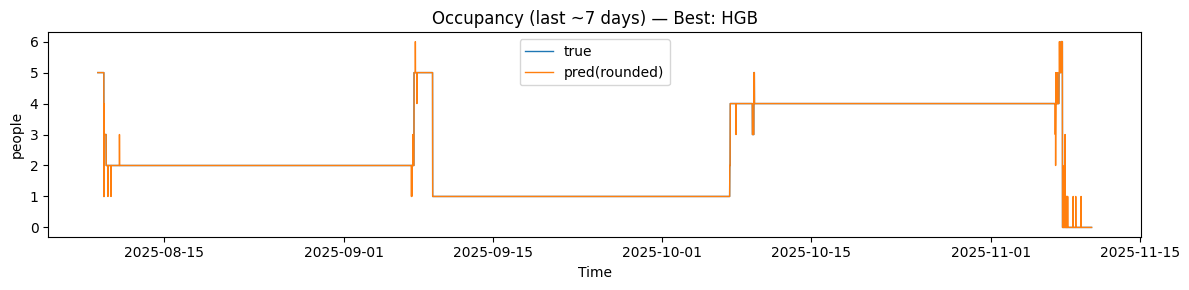

In [ ]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import PoissonRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import joblib

def make_pipe(est):
    return Pipeline([("impute", SimpleImputer(strategy="median")), ("est", est)])

models = {
    "Poisson": make_pipe(PoissonRegressor(alpha=1e-12, max_iter=400)),
    "RF":      make_pipe(RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)),
    "HGB":     make_pipe(HistGradientBoostingRegressor(max_iter=600, learning_rate=0.07,
                                                       random_state=42))
}

tscv = TimeSeriesSplit(n_splits=5)
rows = []
best_name, best_pipe, best_mae = None, None, 1e9

for name, pipe in models.items():
    maes, rmses, acc1s = [], [], []
    for tr, te in tscv.split(X):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y.iloc[tr], y.iloc[te]

        pipe.fit(Xtr, ytr)
        yp = np.clip(pipe.predict(Xte), 0, 8)  # respect capacity
        ypr = np.rint(yp)

        mae  = mean_absolute_error(yte, yp)
        rmse = np.sqrt(((yte - yp) ** 2).mean())           # <- no 'squared' arg
        acc1 = (np.abs(ypr - yte) <= 1).mean()

        maes.append(mae); rmses.append(rmse); acc1s.append(acc1)

    res = {"model": name,
           "MAE": np.mean(maes), "MAE_std": np.std(maes),
           "RMSE": np.mean(rmses), "RMSE_std": np.std(rmses),
           "Acc@±1": np.mean(acc1s), "Acc@±1_std": np.std(acc1s)}
    rows.append(res)
    if res["MAE"] < best_mae:
        best_mae, best_name, best_pipe = res["MAE"], name, pipe

cv_report = pd.DataFrame(rows).round(3).sort_values("MAE")
display(cv_report)

# Fit best on ALL data and save artifacts
best_pipe.fit(X, y)
yhat   = np.clip(best_pipe.predict(X), 0, 8)
yhat_r = np.rint(yhat)

overall = pd.DataFrame({
    "datetime": merged_labeled.index,
    "occ_true": y.values,
    "occ_pred": yhat,
    "occ_pred_round": yhat_r
})

cv_report.to_csv(os.path.join(OUT_DIR, "model_cv_report.csv"), index=False)
overall.to_csv(os.path.join(OUT_DIR, "predictions_all.csv"), index=False)
joblib.dump(best_pipe, os.path.join(OUT_DIR, f"occupancy_{best_name}_best.pkl"))

print(f"\nBest model: {best_name}")
print("ALL-DATA fit (for reference):",
      "MAE=%.3f" % mean_absolute_error(y, yhat),
      "RMSE=%.3f" % np.sqrt(((y - yhat) ** 2).mean()),
      "Acc±1=%.3f" % (np.abs(np.rint(yhat) - y) <= 1).mean())

# quick plot slice
last_week = overall.iloc[-7*24*60:]
plt.figure(figsize=(12,3))
plt.plot(last_week["datetime"], last_week["occ_true"], label="true", linewidth=1)
plt.plot(last_week["datetime"], last_week["occ_pred_round"], label="pred(rounded)", linewidth=1)
plt.legend(); plt.title(f"Occupancy (last ~7 days) — Best: {best_name}")
plt.xlabel("Time"); plt.ylabel("people"); plt.tight_layout(); plt.show()



In [ ]:
# OOF RF predictions + confusion matrix (handles NaNs safely)
import numpy as np, pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, confusion_matrix

rf = Pipeline([("impute", SimpleImputer(strategy="median")),
               ("est", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1))])

tscv = TimeSeriesSplit(n_splits=5)
oof = pd.Series(index=y.index, dtype=float)

for tr, te in tscv.split(X):
    rf.fit(X.iloc[tr], y.iloc[tr])
    yp = np.clip(rf.predict(X.iloc[te]), 0, 8)
    oof.iloc[te] = yp

mask = oof.notna()
y_oof = y[mask]
oof_valid = oof[mask]
oof_r = np.rint(oof_valid).astype(int)

mae_oof = mean_absolute_error(y_oof, oof_valid)
acc1_oof = (np.abs(oof_r - y_oof) <= 1).mean()
print("OOF RF  MAE=%.3f  Acc@±1=%.3f" % (mae_oof, acc1_oof))

labels = list(range(0,9))
cm = pd.DataFrame(confusion_matrix(y_oof.astype(int), oof_r, labels=labels),
                  index=pd.Index(labels, name="True"), columns=pd.Index(labels, name="Pred"))
display(cm)


OOF RF  MAE=1.264  Acc@±1=0.628


Pred,0,1,2,3,4,5,6,7,8
True,,,,,,,,,
0,0,0,0,0,0,0,0,0,0
1,0,1301,12711,1976,657,206,0,0,0
2,0,0,4449,2324,9661,1105,0,0,0
3,0,0,0,0,187,0,0,0,0
4,0,0,0,0,1970,0,0,0,0
5,0,0,517,370,1510,26,0,0,0
6,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0


In [ ]:
# Fast permutation importance on last fold
from sklearn.inspection import permutation_importance
tr, te = list(TimeSeriesSplit(n_splits=5).split(X))[-1]
rf.fit(X.iloc[tr], y.iloc[tr])
perm = permutation_importance(rf, X.iloc[te], y.iloc[te], n_repeats=5, random_state=42, n_jobs=-1)
pi = pd.DataFrame({"feature": X.columns, "importance": perm.importances_mean}) \
       .sort_values("importance", ascending=False)
display(pi.head(12))

In [ ]:
# ===== Feature ablation across models (time-series CV) =====
import numpy as np, pandas as pd, os, warnings
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import PoissonRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore")

def make_pipe(est):
    return Pipeline([("impute", SimpleImputer(strategy="median")), ("est", est)])

models = {
    "Poisson": make_pipe(PoissonRegressor(alpha=1e-12, max_iter=400)),
    "RF":      make_pipe(RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)),
    "HGB":     make_pipe(HistGradientBoostingRegressor(max_iter=600, learning_rate=0.07, random_state=42)),
}

feature_sets = {
    "PIR": ["pir_sum","pir_active","pir_sum_5m","pir_sum_10m"],
    "PIR+CO2": ["pir_sum","pir_active","pir_sum_5m","pir_sum_10m","co2_mean","co2_max","co2_slope_5m"],
    "PIR+CO2+Lx": ["pir_sum","pir_active","pir_sum_5m","pir_sum_10m","co2_mean","co2_max","co2_slope_5m","lx_median","lights_on"],
    "PIR+CO2+Lx+TH": ["pir_sum","pir_active","pir_sum_5m","pir_sum_10m","co2_mean","co2_max","co2_slope_5m","lx_median","lights_on","t_mean","h_mean"],
    "All+Time": FEATS,  # your 14-feature set incl. hour_sin, hour_cos, dow
}

def avail(fs): return [f for f in fs if f in X.columns]

tscv = TimeSeriesSplit(n_splits=5)
rows = []
for fs_name, fs in feature_sets.items():
    feats = avail(fs)
    if not feats:
        continue
    for mname, pipe in models.items():
        maes, rmses, acc1s = [], [], []
        for tr, te in tscv.split(X[feats]):
            Xtr, Xte = X[feats].iloc[tr], X[feats].iloc[te]
            ytr, yte = y.iloc[tr], y.iloc[te]
            pipe.fit(Xtr, ytr)
            yp = np.clip(pipe.predict(Xte), 0, 8)
            ypr = np.rint(yp)
            maes.append(mean_absolute_error(yte, yp))
            rmses.append(np.sqrt(((yte - yp)**2).mean()))
            acc1s.append((np.abs(ypr - yte) <= 1).mean())
        rows.append({
            "feature_set": fs_name, "k": len(feats), "model": mname,
            "MAE": np.mean(maes), "RMSE": np.mean(rmses), "Acc@±1": np.mean(acc1s)
        })

ablation = pd.DataFrame(rows).sort_values(["MAE","RMSE"]).round(3)
display(ablation)
ablation.to_csv(os.path.join(OUT_DIR, "ablation_feature_sets.csv"), index=False)


,feature_set,k,model,MAE,RMSE,Acc@±1
8,PIR+CO2+Lx,9,HGB,1.169,1.385,0.676
7,PIR+CO2+Lx,9,RF,1.186,1.431,0.661
10,PIR+CO2+Lx+TH,11,RF,1.251,1.485,0.640
13,All+Time,14,RF,1.264,1.482,0.628
11,PIR+CO2+Lx+TH,11,HGB,1.265,1.486,0.632
14,All+Time,14,HGB,1.268,1.454,0.639
5,PIR+CO2,7,HGB,1.297,1.468,0.600
1,PIR,4,RF,1.307,1.446,0.538
2,PIR,4,HGB,1.312,1.435,0.544
4,PIR+CO2,7,RF,1.315,1.523,0.581


# **train and save best config**

In [ ]:
# ============================================
# Occupancy model — full pipeline (from merged CSV + responses)
# ============================================

# ---- Imports
import os, re, warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, confusion_matrix
import joblib

warnings.filterwarnings("ignore", message="Could not infer format.*", category=UserWarning)

# ---- Paths (adjust if needed)
MERGED_CSV = "/content/drive/MyDrive/secondment/workings/Pilot_Final/Workroom/Results/WR_MERGED_asof_NoOverlapTrim_Jul21_Oct06.csv"
RESP_CSV   = "/content/drive/MyDrive/secondment/workings/Pilot_Final/Workroom/Data/WR_responses.csv"
OUT_DIR    = "/content/drive/MyDrive/secondment/workings/Pilot_Final/Workroom/Results"
os.makedirs(OUT_DIR, exist_ok=True)

# ---- Helpers (CSV reader + datetime parser)
def read_csv_smart(path):
    try:
        df = pd.read_csv(path, sep=None, engine="python", encoding="utf-8-sig")
    except Exception:
        df = pd.read_csv(path, sep=",", encoding="utf-8-sig")
    if df.shape[1] == 1:
        head = str(df.columns[0]); first = str(df.iloc[0,0]) if not df.empty else ""
        if ";" in head or ";" in first:
            df = pd.read_csv(path, sep=";", engine="python", encoding="utf-8-sig")
        else:
            df = pd.read_csv(path, sep=",", encoding="utf-8-sig")
    return df

def detect_time_columns(cols):
    cset = [str(c).strip() for c in cols]
    date_like = [c for c in cset if re.search(r'\bdate\b', c, re.I)]
    time_like = [c for c in cset if re.search(r'\btime\b', c, re.I)]
    if date_like and time_like:
        return ("__DATE__", "__TIME__", date_like[0], time_like[0])
    for pat in (r'\btimestamp\b', r'date\s*[/_-]?\s*time', r'\blog\s*time\b', r'\btime\b'):
        for c in cset:
            if re.search(pat, c, re.I):
                return (c,)
    return (cset[0],)

def parse_datetime_series(df):
    spec = detect_time_columns(df.columns)
    if len(spec) == 4 and spec[0] == "__DATE__":
        date_col, time_col = spec[2], spec[3]
        s = (df[date_col].astype(str).strip() + " " + df[time_col].astype(str).strip())
    else:
        ts_col = spec[0]
        s = df[ts_col].astype(str).str.strip()
    dt = pd.to_datetime(s, errors="coerce", utc=True, dayfirst=True)
    if dt.isna().mean() > 0.5:
        num = pd.to_numeric(s, errors="coerce")
        if num.notna().sum() > 0:
            dt = pd.to_datetime(num, unit="s", errors="coerce", utc=True)
            if dt.isna().mean() > 0.5:
                dt = pd.to_datetime(num, unit="ms", errors="coerce", utc=True)
    return dt

# ============================================
# 1) LOAD MERGED SENSORS + RESPONSES, BUILD LABEL (causal/backward)
# ============================================
merged = pd.read_csv(MERGED_CSV, parse_dates=["datetime"]).sort_values("datetime")
merged = merged.drop_duplicates(subset=["datetime"], keep="first").set_index("datetime")

resp_raw = read_csv_smart(RESP_CSV)
resp_dt = parse_datetime_series(resp_raw)
resp = pd.DataFrame({"datetime": resp_dt})

# find pax column
pax_col = None
for c in resp_raw.columns:
    if str(c).strip().lower() in {"pax","occupancy","count","people","headcount"}:
        pax_col = c; break
if pax_col is None:
    pax_col = "pax"

resp["pax"] = pd.to_numeric(resp_raw[pax_col], errors="coerce").clip(0, 8)
resp = resp.dropna(subset=["datetime","pax"]).sort_values("datetime")

# causal/backward alignment: for each sensor row, take the most recent past pax
timeline = pd.DataFrame({"datetime": merged.index})
aligned = pd.merge_asof(
    timeline.sort_values("datetime"),
    resp[["datetime","pax"]].sort_values("datetime"),
    on="datetime",
    direction="backward"
)

first_known = aligned["pax"].first_valid_index()
aligned = aligned.loc[first_known:].copy()
merged_labeled = merged.loc[aligned["datetime"]].copy()
merged_labeled["occ"] = aligned["pax"].values.astype(float)

print("Label rows:", len(merged_labeled),
      "| span:", merged_labeled.index.min(), "→", merged_labeled.index.max(),
      "| NaNs in label:", int(merged_labeled["occ"].isna().sum()))

# ============================================
# 2) FEATURE ENGINEERING (PIR/CO2/Lux + minimal context)
# ============================================
df = merged_labeled.copy()

WR_IDS  = [f"WR{i}"  for i in range(1,9)]
IEQ_IDS = [f"IEQ{i}" for i in range(1,5)]
def existing(cols): return [c for c in cols if c in df.columns]

pir_cols_wr  = existing([f"PIR_{sid}" for sid in WR_IDS])
co2_cols_ieq = existing([f"CO2_{sid}" for sid in IEQ_IDS])
lx_cols_wr   = existing([f"Lx_{sid}" for sid in WR_IDS])
t_cols_ieq   = existing([f"T_{sid}"   for sid in IEQ_IDS])
h_cols_ieq   = existing([f"H_{sid}"   for sid in IEQ_IDS])

# Instantaneous aggregates
df["pir_sum"]     = df[pir_cols_wr].fillna(0).sum(axis=1) if pir_cols_wr else 0
df["pir_active"]  = df[pir_cols_wr].gt(0).sum(axis=1)     if pir_cols_wr else 0
df["co2_mean"]    = df[co2_cols_ieq].mean(axis=1)         if co2_cols_ieq else np.nan
df["co2_max"]     = df[co2_cols_ieq].max(axis=1)          if co2_cols_ieq else np.nan
df["lx_median"]   = df[lx_cols_wr].median(axis=1)         if lx_cols_wr else np.nan
df["lights_on"]   = (df["lx_median"] > 50).astype(int)

df["t_mean"]      = df[t_cols_ieq].mean(axis=1)           if t_cols_ieq else np.nan
df["h_mean"]      = df[h_cols_ieq].mean(axis=1)           if h_cols_ieq else np.nan

# Causal rolling / slopes (index is DateTimeIndex already)
def time_roll(s, window): return s.rolling(window=window, min_periods=1)

if pir_cols_wr:
    pir_sum_series = df[pir_cols_wr].fillna(0).sum(axis=1)
    df["pir_sum_5m"]  = time_roll(pir_sum_series,  "5min").sum()
    df["pir_sum_10m"] = time_roll(pir_sum_series, "10min").sum()

if "co2_mean" in df:
    df["co2_slope_5m"] = (df["co2_mean"] - df["co2_mean"].shift(5)) / 5.0

# Time-of-day (optional; not in BEST_FEATS but we compute in case you need it)
df["hour"] = df.index.hour
df["dow"]  = df.index.dayofweek
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

# Target
y = df["occ"].copy()

# ---- Best feature set from your ablation
BEST_FEATS = ["pir_sum","pir_active","pir_sum_5m","pir_sum_10m",
              "co2_mean","co2_max","co2_slope_5m",
              "lx_median","lights_on"]

# keep only those that exist
BEST_FEATS = [f for f in BEST_FEATS if f in df.columns]
X = df[BEST_FEATS].copy()

print("Using features:", BEST_FEATS)
print("X shape:", X.shape, "| y:", y.notna().sum())

# ============================================
# 3) TRAIN + OOF EVALUATION + SAVE ARTIFACTS (HGB + PIR+CO2+Lux)
# ============================================
best = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("est", HistGradientBoostingRegressor(max_iter=600, learning_rate=0.07, random_state=42))
])

tscv = TimeSeriesSplit(n_splits=5)
oof = pd.Series(index=y.index, dtype=float)

# time-series CV (OOF predictions)
for tr, te in tscv.split(X):
    best.fit(X.iloc[tr], y.iloc[tr])
    preds = np.clip(best.predict(X.iloc[te]), 0, 8)
    oof.iloc[te] = preds

# Drop NaNs (earliest rows not in any test fold)
mask = oof.notna()
y_oof   = y[mask]
oof_val = oof[mask]
oof_round = np.rint(oof_val).astype(int)

MAE  = mean_absolute_error(y_oof, oof_val)
RMSE = float(np.sqrt(((y_oof - oof_val) ** 2).mean()))
ACC1 = float((np.abs(oof_round - y_oof) <= 1).mean())
print("\nOOF (HGB, PIR+CO2+Lux):  MAE=%.3f  RMSE=%.3f  Acc@±1=%.3f" % (MAE, RMSE, ACC1))

# Confusion matrix (rounded to nearest person)
labels = list(range(0,9))
cm = pd.DataFrame(
    confusion_matrix(y_oof.astype(int), oof_round, labels=labels),
    index=pd.Index(labels, name="True"),
    columns=pd.Index(labels, name="Pred")
)
print("\nConfusion matrix (rounded counts):")
print(cm.to_string())

# Save artifacts
joblib.dump(best.fit(X, y), os.path.join(OUT_DIR, "occupancy_HGB_PIR_CO2_Lx.pkl"))
pd.DataFrame({
    "metric":["MAE","RMSE","Acc@±1"], "value":[MAE, RMSE, ACC1]
}).to_csv(os.path.join(OUT_DIR, "metrics_oof_HGB_PIR_CO2_Lx.csv"), index=False)
cm.to_csv(os.path.join(OUT_DIR, "confusion_matrix_oof_HGB_PIR_CO2_Lx.csv"))

# Also save OOF predictions aligned to timestamps for auditing
oof_df = pd.DataFrame({
    "datetime": y_oof.index,
    "occ_true": y_oof.values,
    "occ_pred": oof_val.values,
    "occ_pred_round": oof_round.values
})
oof_df.to_csv(os.path.join(OUT_DIR, "oof_predictions_HGB_PIR_CO2_Lx.csv"), index=False)

print("\nSaved to:", OUT_DIR)



Label rows: 46769 | span: 2025-07-21 00:02:29+00:00 → 2025-09-30 23:57:18+00:00 | NaNs in label: 0
Using features: ['pir_sum', 'pir_active', 'pir_sum_5m', 'pir_sum_10m', 'co2_mean', 'co2_max', 'co2_slope_5m', 'lx_median', 'lights_on']
X shape: (46769, 9) | y: 46769

OOF (HGB, PIR+CO2+Lux):  MAE=1.169  RMSE=1.391  Acc@±1=0.676

Confusion matrix (rounded counts):
Pred  0     1      2     3     4   5  6  7  8
True                                         
0     0     0      0     0     0   0  0  0  0
1     0  1066  11711  3254   799  21  0  0  0
2     0     0   5510  4627  7355  47  0  0  0
3     0     0      0     0   187   0  0  0  0
4     0     0      0     0  1970   0  0  0  0
5     0     0   1014   141  1267   1  0  0  0
6     0     0      0     0     0   0  0  0  0
7     0     0      0     0     0   0  0  0  0
8     0     0      0     0     0   0  0  0  0

Saved to: /content/drive/MyDrive/secondment/workings/Pilot_Final/Workroom/Results


Built CM from OOF: n=38970 rows, classes present: [1 2 3 4 5]


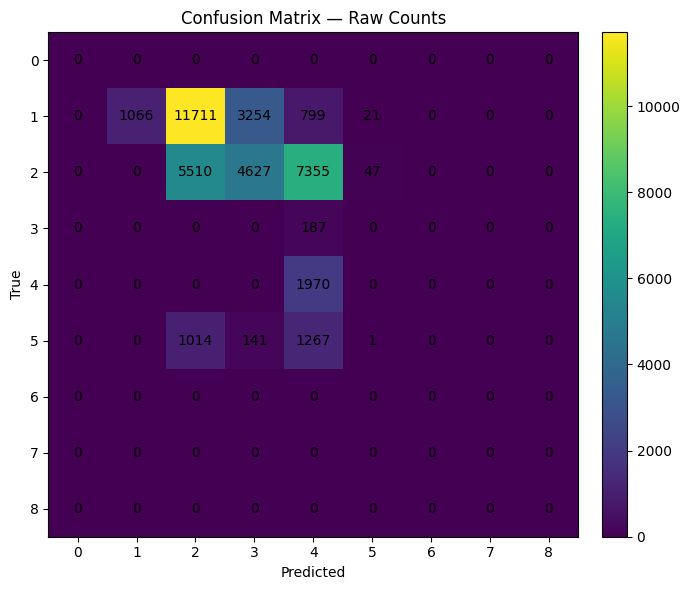

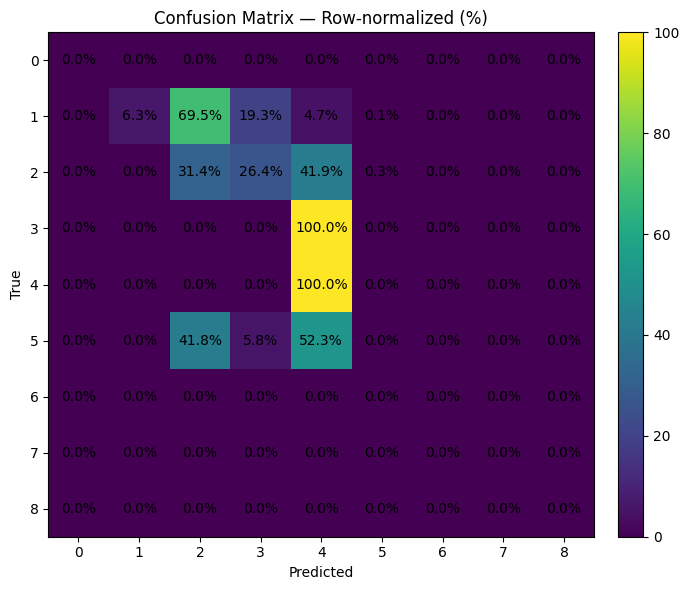

Saved:
   /content/drive/MyDrive/secondment/workings/Pilot_Final/Workroom/Results/cm_raw.png
   /content/drive/MyDrive/secondment/workings/Pilot_Final/Workroom/Results/cm_normalized.png


In [ ]:
# ============================================
# Robust confusion matrix viz (handles dtype mismatch; rebuilds from OOF)
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

OUT_DIR = "/content/drive/MyDrive/secondment/workings/Pilot_Final/Workroom/Results"
OOF_CSV = os.path.join(OUT_DIR, "oof_predictions_HGB_PIR_CO2_Lx.csv")
CM_CSV  = os.path.join(OUT_DIR, "confusion_matrix_oof_HGB_PIR_CO2_Lx.csv")
labels  = list(range(0, 9))  # 0..8 people

def load_cm():
    # Prefer rebuilding from OOF predictions to avoid label dtype issues
    if os.path.exists(OOF_CSV):
        oof = pd.read_csv(OOF_CSV, parse_dates=["datetime"])
        assert {"occ_true"}.issubset(oof.columns), "OOF file missing occ_true"
        # pick rounded if present, else round the float preds
        if "occ_pred_round" in oof.columns:
            y_pred = oof["occ_pred_round"].astype(int).to_numpy()
        else:
            y_pred = np.rint(oof["occ_pred"].to_numpy()).astype(int)
        y_true = oof["occ_true"].astype(int).to_numpy()
        y_pred = np.clip(y_pred, 0, 8)
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        cm_df = pd.DataFrame(cm, index=pd.Index(labels, name="True"),
                                 columns=pd.Index(labels, name="Pred"))
        print(f"Built CM from OOF: n={len(oof)} rows, classes present:", np.unique(y_true))
        return cm_df

    # Fallback: load the saved matrix and coerce label dtypes
    assert os.path.exists(CM_CSV), "Run the training/OOF cell first to create predictions or CM CSV."
    cm_df = pd.read_csv(CM_CSV, index_col=0)
    # Coerce index/columns to int (they may be strings "0","1",...)
    try:
        cm_df.index = cm_df.index.astype(int)
        cm_df.columns = cm_df.columns.astype(int)
    except Exception:
        pass
    # Reindex to enforce order and include any missing classes
    cm_df = cm_df.reindex(index=labels, columns=labels, fill_value=0)
    print("Loaded CM from CSV; total count:", int(cm_df.values.sum()))
    return cm_df

def plot_cm(mat_df, title, save_path=None, fmt="int"):
    fig = plt.figure(figsize=(7, 6))
    ax = plt.gca()
    im = ax.imshow(mat_df.values, aspect="auto", origin="upper")
    ax.set_xticks(range(len(mat_df.columns))); ax.set_yticks(range(len(mat_df.index)))
    ax.set_xticklabels(mat_df.columns); ax.set_yticklabels(mat_df.index)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)

    vals = mat_df.values
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            txt = f"{int(vals[i,j])}" if fmt=="int" else f"{vals[i,j]:.1f}%"
            ax.text(j, i, txt, ha="center", va="center")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=160)
    plt.show()

cm_df = load_cm()

# Raw counts
raw_path = os.path.join(OUT_DIR, "cm_raw.png")
plot_cm(cm_df, "Confusion Matrix — Raw Counts", save_path=raw_path, fmt="int")

# Row-normalized (% of each true class)
row_sums = cm_df.sum(axis=1).replace(0, np.nan)
cm_norm = (cm_df.T / row_sums).T.fillna(0) * 100.0
norm_path = os.path.join(OUT_DIR, "cm_normalized.png")
plot_cm(cm_norm.round(1), "Confusion Matrix — Row-normalized (%)", save_path=norm_path, fmt="pct")

print("Saved:")
print("  ", raw_path)
print("  ", norm_path)


new part with featurs created january 2026:

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# Helper
def make_pipe(est):
    return Pipeline([("impute", SimpleImputer(strategy="median")), ("est", est)])

# --- Define your sensor strategies ---
strategies = {
    "PIR_only": [
        "pir_sum", "pir_active", "pir_sum_5m", "pir_sum_10m"
    ],
    "Desk_CO2+PIR": [
        "pir_sum", "pir_active", "pir_sum_5m", "pir_sum_10m",
        "co2_mean", "co2_slope_5m"
    ],
    "Desk_CO2+T+PIR": [
        "pir_sum", "pir_active", "pir_sum_5m", "pir_sum_10m",
        "co2_mean", "co2_slope_5m",
        "t_mean"
    ],
    "Ceiling_only": [
        "CO2_CEIL1", "T_CEIL1", "H_CEIL1", "PIR_CEIL1",
        "CO2_CEIL2", "T_CEIL2", "H_CEIL2", "PIR_CEIL2"
    ],
    "Full_Desk_IEQ": [
        "CO2_IEQ1", "T_IEQ1", "PIR_IEQ1", "Lx_IEQ1", "H_IEQ1",
        "CO2_IEQ2", "T_IEQ2", "PIR_IEQ2", "Lx_IEQ2", "H_IEQ2",
        "CO2_IEQ3", "T_IEQ3", "PIR_IEQ3", "Lx_IEQ3", "H_IEQ3",
        "CO2_IEQ4", "T_IEQ4", "PIR_IEQ4", "Lx_IEQ4", "H_IEQ4"
    ],
    "WR_only": [
        col for col in df.columns if any(col.startswith(x) for x in ["PIR_WR", "T_WR", "CO2_WR", "H_WR", "Lx_WR"])
    ],
    "Full_Fusion": list(X.columns)  # use all engineered features
}

# --- Model and CV ---
model = make_pipe(RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
tscv = TimeSeriesSplit(n_splits=5)

results = []

for name, feats in strategies.items():
    feats_exist = [f for f in feats if f in df.columns]
    if not feats_exist:
        print(f"⚠️ Skipping {name}: no features found.")
        continue

    Xsub = df[feats_exist]
    maes, rmses, acc1s = [], [], []

    for tr, te in tscv.split(Xsub):
        Xtr, Xte = Xsub.iloc[tr], Xsub.iloc[te]
        ytr, yte = y.iloc[tr], y.iloc[te]

        model.fit(Xtr, ytr)
        yp = np.clip(model.predict(Xte), 0, 8)
        ypr = np.rint(yp)

        maes.append(mean_absolute_error(yte, yp))
        rmse = np.sqrt(((yte - yp) ** 2).mean())
        rmses.append(rmse)
        acc1s.append((np.abs(ypr - yte) <= 1).mean())

    results.append({
        "Strategy": name,
        "n_features": len(feats_exist),
        "MAE": np.mean(maes), "MAE_std": np.std(maes),
        "RMSE": np.mean(rmses), "RMSE_std": np.std(rmses),
        "Acc@±1": np.mean(acc1s), "Acc@±1_std": np.std(acc1s),
    })

# --- Show Results ---
results_df = pd.DataFrame(results).sort_values("MAE").round(3)
display(results_df)


,Strategy,n_features,MAE,MAE_std,RMSE,RMSE_std,Acc@±1,Acc@±1_std
5,WR_only,40,1.844,0.966,2.177,0.896,0.518,0.306
0,PIR_only,4,1.871,0.794,2.155,0.673,0.432,0.251
4,Full_Desk_IEQ,20,1.932,0.944,2.211,0.895,0.473,0.338
3,Ceiling_only,8,1.967,0.883,2.276,0.885,0.456,0.292
6,Full_Fusion,17,1.978,0.319,2.268,0.362,0.315,0.140
1,Desk_CO2+PIR,6,2.031,0.903,2.288,0.857,0.429,0.296
2,Desk_CO2+T+PIR,7,2.112,0.936,2.402,0.868,0.395,0.311


,Strategy,n_features,MAE,MAE_std,RMSE,RMSE_std,Acc@±1,Acc@±1_std
5,WR_only,41,1.758,0.843,2.104,0.796,0.507,0.312
2,Desk_CO2+T+PIR,36,1.765,0.971,2.063,0.925,0.562,0.342
0,PIR_only,8,1.859,0.753,2.145,0.642,0.449,0.252
1,Desk_CO2+PIR,24,1.894,0.956,2.137,0.888,0.465,0.352
4,Full_Desk_IEQ,20,1.923,0.945,2.202,0.898,0.476,0.341
7,PIR_WR+IEQ_env,24,1.935,0.976,2.212,0.921,0.475,0.342
6,Full_Fusion,17,1.979,0.315,2.268,0.355,0.314,0.138
3,Ceiling_only,10,2.074,0.825,2.362,0.858,0.436,0.285



✅ Best strategy: WR_only
✅ ALL-DATA fit: MAE=0.020 RMSE=0.078 Acc@±1=1.000


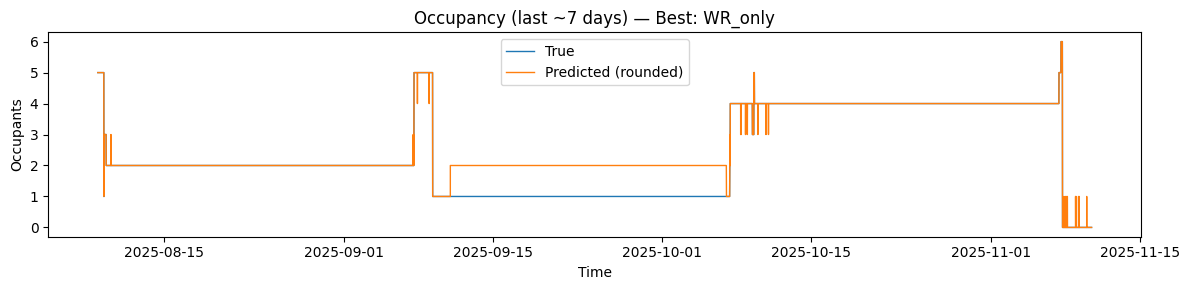

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import PoissonRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import joblib

# ========== Model Pipeline ==========
def make_pipe(est):
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("est", est)
    ])

models = {
    "Poisson": make_pipe(PoissonRegressor(alpha=1e-12, max_iter=400)),
    "RF":      make_pipe(RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)),
    "HGB":     make_pipe(HistGradientBoostingRegressor(max_iter=600, learning_rate=0.07, random_state=42))
}

tscv = TimeSeriesSplit(n_splits=5)

# ========== Strategies ==========
all_cols = df.columns.tolist()

strategies = {
    "PIR_only":           [c for c in all_cols if c.startswith("PIR_") and "_WR" in c],
    "Desk_CO2+PIR":       [c for c in all_cols if ("CO2_" in c or "PIR_" in c) and ("IEQ" in c or "WR" in c)],
    "Desk_CO2+T+PIR":     [c for c in all_cols if ("CO2_" in c or "T_" in c or "PIR_" in c) and ("IEQ" in c or "WR" in c)],
    "Ceiling_only":       [c for c in all_cols if any(c.endswith(f"_{sid}") for sid in ["CEIL1", "CEIL2"])],
    "Full_Desk_IEQ":      [c for c in all_cols if "_IEQ" in c],
    "WR_only":            [c for c in all_cols if "_WR" in c],
    "Full_Fusion":        X.columns.tolist(),
    "PIR_WR+IEQ_env":     [  # new strategy
        *[f"PIR_WR{i}" for i in range(1, 9) if f"PIR_WR{i}" in all_cols],
        *[f"{var}_IEQ{i}" for i in range(1, 5) for var in ["T", "CO2", "H", "Lx"] if f"{var}_IEQ{i}" in all_cols]
    ]
}

# ========== Run CV for each strategy ==========
results = []
best_model = None
best_score = float("inf")

for strat_name, feat_cols in strategies.items():
    Xs = df[feat_cols].copy()
    ys = df["occ"]

    maes, rmses, acc1s = [], [], []

    for tr_idx, te_idx in tscv.split(Xs):
        Xtr, Xte = Xs.iloc[tr_idx], Xs.iloc[te_idx]
        ytr, yte = ys.iloc[tr_idx], ys.iloc[te_idx]

        pipe = models["RF"]
        pipe.fit(Xtr, ytr)

        yp = np.clip(pipe.predict(Xte), 0, 8)
        ypr = np.rint(yp)

        maes.append(mean_absolute_error(yte, yp))
        rmses.append(np.sqrt(((yte - yp) ** 2).mean()))
        acc1s.append((np.abs(ypr - yte) <= 1).mean())

    res = {
        "Strategy": strat_name,
        "n_features": len(feat_cols),
        "MAE": np.mean(maes), "MAE_std": np.std(maes),
        "RMSE": np.mean(rmses), "RMSE_std": np.std(rmses),
        "Acc@±1": np.mean(acc1s), "Acc@±1_std": np.std(acc1s),
    }
    results.append(res)

    if res["MAE"] < best_score:
        best_score = res["MAE"]
        best_model = pipe
        best_featset = feat_cols
        best_name = strat_name

# ========== Save & Plot ==========
cv_report = pd.DataFrame(results).round(3).sort_values("MAE")
display(cv_report)

# Final fit on all data for best strategy
Xs = df[best_featset]
ys = df["occ"]
best_model.fit(Xs, ys)

yp_all = np.clip(best_model.predict(Xs), 0, 8)
yp_round = np.rint(yp_all)

preds_df = pd.DataFrame({
    "datetime": df.index,
    "occ_true": ys.values,
    "occ_pred": yp_all,
    "occ_pred_round": yp_round
})

cv_report.to_csv(os.path.join(OUT_DIR, "model_cv_report.csv"), index=False)
preds_df.to_csv(os.path.join(OUT_DIR, "predictions_all.csv"), index=False)
joblib.dump(best_model, os.path.join(OUT_DIR, f"occupancy_{best_name}_best.pkl"))

print(f"\n✅ Best strategy: {best_name}")
print("✅ ALL-DATA fit:",
      "MAE=%.3f" % mean_absolute_error(ys, yp_all),
      "RMSE=%.3f" % np.sqrt(((ys - yp_all) ** 2).mean()),
      "Acc@±1=%.3f" % (np.abs(np.rint(yp_all) - ys) <= 1).mean())

# Plot
last_week = preds_df.iloc[-7*24*60:]
plt.figure(figsize=(12,3))
plt.plot(last_week["datetime"], last_week["occ_true"], label="True", linewidth=1)
plt.plot(last_week["datetime"], last_week["occ_pred_round"], label="Predicted (rounded)", linewidth=1)
plt.legend(); plt.title(f"Occupancy (last ~7 days) — Best: {best_name}")
plt.xlabel("Time"); plt.ylabel("Occupants"); plt.tight_layout(); plt.show()


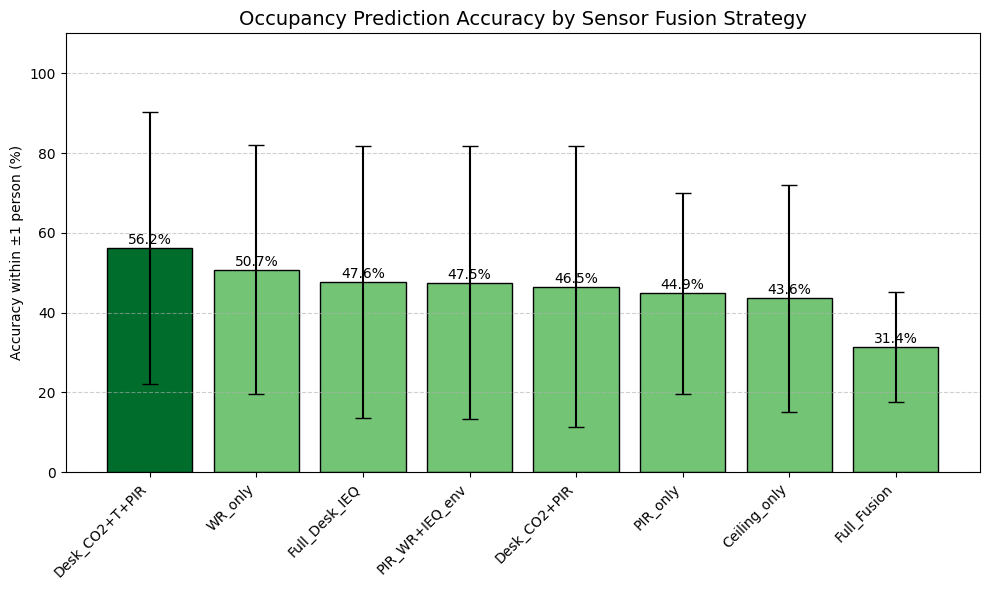

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==== Convert Acc@±1 to Percent ====
cv_report["Acc@±1 (%)"] = (cv_report["Acc@±1"] * 100).round(1)
cv_report["Acc@±1_std (%)"] = (cv_report["Acc@±1_std"] * 100).round(1)

# ==== Sort by Accuracy ====
cv_sorted = cv_report.sort_values("Acc@±1", ascending=False).reset_index(drop=True)

# ==== Highlight best ====
best_strategy = cv_sorted.loc[0, "Strategy"]

# ==== Bar Colors: highlight best ====
colors = ["#006d2c" if s == best_strategy else "#74c476" for s in cv_sorted["Strategy"]]

# ==== Plot ====
plt.figure(figsize=(10, 6))
bars = plt.bar(
    x=cv_sorted["Strategy"],
    height=cv_sorted["Acc@±1 (%)"],
    yerr=cv_sorted["Acc@±1_std (%)"],
    capsize=6,
    color=colors,
    edgecolor="black"
)

# ==== Annotate Bars ====
for bar, value in zip(bars, cv_sorted["Acc@±1 (%)"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f"{value}%", ha="center", fontsize=10)

# ==== Aesthetics ====
plt.ylabel("Accuracy within ±1 person (%)")
plt.title("Occupancy Prediction Accuracy by Sensor Fusion Strategy", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
